# Hoi quy da lop

In [6]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score
from sklearn.metrics import confusion_matrix
# from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
%matplotlib inline
plt.style.use('seaborn-v0_8-white')

In [7]:
from sklearn.datasets import load_iris, load_wine
X=load_iris().data
y=load_iris().target

In [8]:
# Add noisy features to make the problem harder
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
for i in range(n_samples):
    for j in range(n_features):
        X[i,j]=X[i,j]+random_state.randn()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = LogisticRegression(multi_class='multinomial')
model.fit(X_train,y_train)
b=model.intercept_
w=model.coef_
print(b)
print(w)

[ 2.98060673  2.02349175 -5.00409848]
[[ 0.14570359  0.84008242 -1.91619159 -0.40885508]
 [-0.19669307 -0.46923679  0.45004096  0.08731467]
 [ 0.05098948 -0.37084563  1.46615063  0.32154041]]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# Viết rõ mô hình hồi quy đa lớp (Softmax Regression)

Tổ hợp tuyến tính $z_k$ cho 3 lớp ($k \in \{0, 1, 2\}$):

$$z_0 = 2.9807 + 0.1457 \cdot x_1 + 0.8401 \cdot x_2 - 1.9162 \cdot x_3 - 0.4090 \cdot x_4$$

$$z_1 = 2.0231 - 0.1967 \cdot x_1 - 0.4692 \cdot x_2 + 0.4501 \cdot x_3 + 0.0872 \cdot x_4$$

$$z_2 = -5.0038 + 0.0510 \cdot x_1 - 0.3709 \cdot x_2 + 1.4661 \cdot x_3 + 0.3217 \cdot x_4$$

Mô hình xác suất theo hàm **Softmax**:

$$P(y=0 \mid x) = \frac{e^{z_0}}{e^{z_0} + e^{z_1} + e^{z_2}}$$

$$P(y=1 \mid x) = \frac{e^{z_1}}{e^{z_0} + e^{z_1} + e^{z_2}}$$

$$P(y=2 \mid x) = \frac{e^{z_2}}{e^{z_0} + e^{z_1} + e^{z_2}}$$

Trong đó:
- $x_1, x_2, x_3, x_4$: 4 đặc trưng đầu vào (Sepal Length, Sepal Width, Petal Length, Petal Width).
- $y \in \{0, 1, 2\}$: 3 loài hoa (0: Setosa, 1: Versicolor, 2: Virginica).


In [11]:
x_test=X_test[0]
z=np.dot(x_test,w.T)+b
print(z)

[-4.03422701  1.81208945  2.22213756]


In [12]:
proba=np.exp(z)/np.sum(np.exp(z))
print(proba)

[0.0011517  0.39844117 0.60040713]


##  Confution matrix

In [13]:
y_train_pred=model.predict(X_train)
print(confusion_matrix(y_train,y_train_pred))

[[39  1  0]
 [ 2 30  9]
 [ 0 11 28]]


<Figure size 800x800 with 0 Axes>

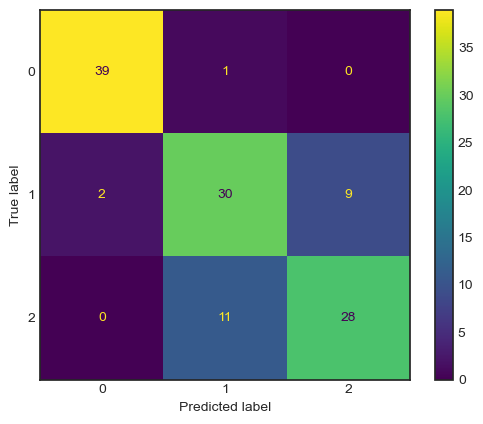

In [14]:
plt.figure(figsize=(8,8))
ConfusionMatrixDisplay.from_estimator(model,X_train,y_train)
plt.show()

In [15]:
print(classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        40
           1       0.71      0.73      0.72        41
           2       0.76      0.72      0.74        39

    accuracy                           0.81       120
   macro avg       0.81      0.81      0.81       120
weighted avg       0.81      0.81      0.81       120



## Roc curve

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [17]:
y_train_pred = model.predict_proba(X_train)
y_train_binarize=label_binarize(y_train, classes=[0, 1, 2])

In [18]:
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_train_binarize[:, i], y_train_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_train_binarize.ravel(), y_train_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

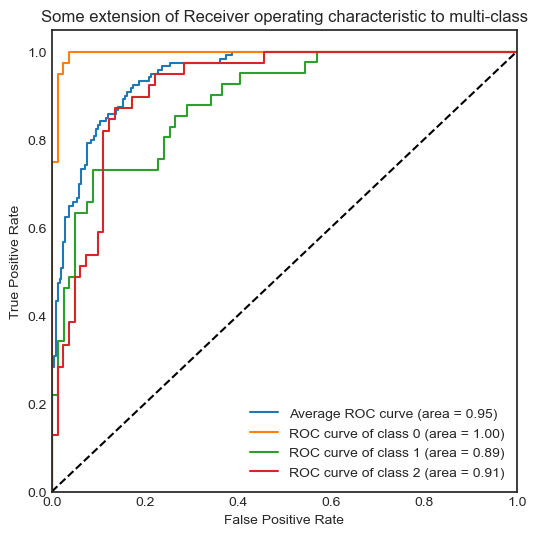

In [19]:
# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr["micro"], tpr["micro"],
         label='Average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                   ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()


In [20]:
y_test_pred = model.predict_proba(X_test)
y_test_binarize=label_binarize(y_test, classes=[0, 1, 2])
#y_train_binarize

In [21]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarize[:, i], y_test_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarize.ravel(), y_test_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

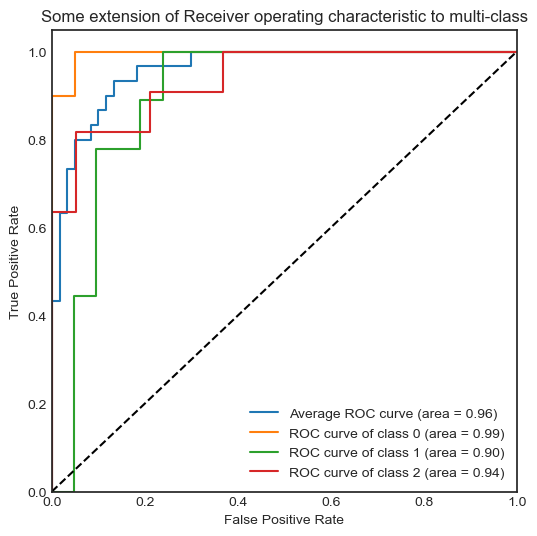

In [22]:
# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr["micro"], tpr["micro"],
         label='Average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                   ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()